In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
data = {'level':[1,2,3,4,5,6,7,8,9,10],
        'salary':[45000,50000,60000,80000,110000,150000,200000,300000,500000,1000000]}
data

{'level': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'salary': [45000,
  50000,
  60000,
  80000,
  110000,
  150000,
  200000,
  300000,
  500000,
  1000000]}

In [3]:
df = pd.DataFrame(data)
df

,level,salary
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,300000
8,9,500000
9,10,1000000


In [4]:
x=df[['level']]
x

,level
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [5]:
y=df['salary']
y

0      45000
1      50000
2      60000
3      80000
4     110000
5     150000
6     200000
7     300000
8     500000
9    1000000
Name: salary, dtype: int64

In [6]:
lr = LinearRegression()
lr.fit(x,y)
y_pred = lr.predict(x).round(2)
y_pred

array([-114454.55,  -33575.76,   47303.03,  128181.82,  209060.61,
        289939.39,  370818.18,  451696.97,  532575.76,  613454.55])

In [7]:
from sklearn.metrics import r2_score,mean_squared_error

In [8]:
print(r2_score(y,y_pred))

0.6690412358828437


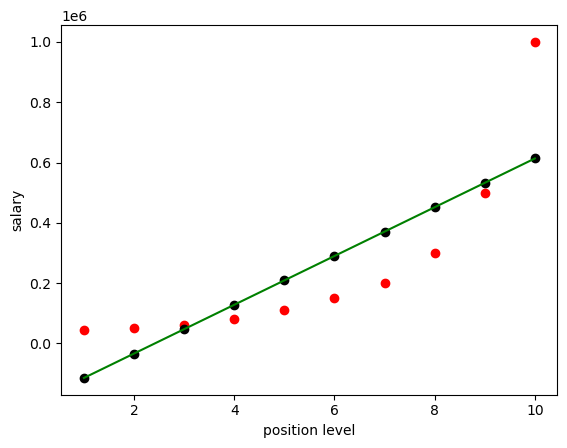

In [18]:
plt.scatter(x,y,color='red',label='actual salary data')
plt.plot(x,y_pred,color='green',label='Linear Regression')
plt.scatter(x,y_pred,color='Black',label='Linear Regression')
plt.xlabel('position level')
plt.ylabel('salary')
plt.show()

In [10]:
poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)
x_poly

array([[   1.,    1.,    1.,    1.],
       [   1.,    2.,    4.,    8.],
       [   1.,    3.,    9.,   27.],
       [   1.,    4.,   16.,   64.],
       [   1.,    5.,   25.,  125.],
       [   1.,    6.,   36.,  216.],
       [   1.,    7.,   49.,  343.],
       [   1.,    8.,   64.,  512.],
       [   1.,    9.,   81.,  729.],
       [   1.,   10.,  100., 1000.]])

In [11]:
poly_reg = LinearRegression()
poly_reg.fit(x_poly,y)
poly_y = poly_reg.predict(x_poly)

In [12]:
print(r2_score(y,poly_y))

0.9812097727913367


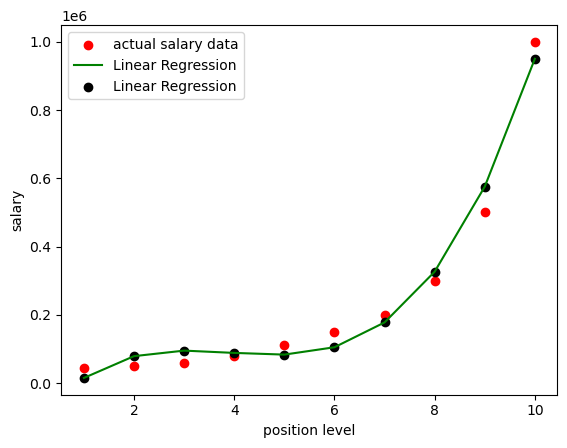

In [20]:
plt.scatter(x,y,color='red',label='actual salary data')
plt.plot(x,poly_y,color='green',label='Linear Regression')
plt.scatter(x,poly_y,color='black',label='Linear Regression')
plt.xlabel('position level')
plt.ylabel('salary')
plt.legend()
plt.show()

In [14]:
from sklearn.linear_model import Ridge,Lasso

In [15]:
rm = Ridge()
rm.fit(x,y)
y_rd = rm.predict(x).round(2)
y_rd

array([-110095.81,  -30185.63,   49724.55,  129634.73,  209544.91,
        289455.09,  369365.27,  449275.45,  529185.63,  609095.81])

In [16]:
r2_score(y,y_rd)

0.6689452755413183

In [17]:
lr = Lasso(alpha=1,max_iter=200)
lr.fit(x,y)
y_pred=lr.predict(x).round()
r2_score(y,y_pred)

0.6690412271043766